<a href="https://colab.research.google.com/github/kunal13-Ai/Australian-Weather-Forecast/blob/main/AUS_weather_Trainig_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [107]:
df = pd.read_csv('/content/weatherAUS.csv.zip')

In [108]:
df.sample(6)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
54478,2015-10-11,MountGinini,6.9,13.5,1.6,NaN,NaN,WSW,52.0,W,...,98.0,98.0,NaN,NaN,NaN,NaN,7.6,7.8,Yes,No
43063,2010-05-01,Wollongong,15.5,21.6,0.0,NaN,NaN,NNE,35.0,SSW,...,68.0,77.0,1027.6,1024.2,8.0,7.0,19.1,20.9,No,No
922,2011-07-11,Albury,4.7,11.8,6.6,NaN,NaN,W,30.0,WNW,...,85.0,64.0,1022.2,1022.7,6.0,8.0,5.7,11.2,Yes,No
134369,2012-08-30,Launceston,5.1,14.3,14.0,NaN,NaN,NW,35.0,NW,...,86.0,57.0,1001.9,1002.3,NaN,NaN,9.2,13.4,Yes,No
15334,2009-08-16,Newcastle,6.4,24.8,0.0,NaN,NaN,NaN,NaN,W,...,53.0,33.0,NaN,NaN,0.0,1.0,13.8,24.0,No,No
135048,2014-09-07,Launceston,5.0,18.4,0.0,NaN,NaN,NNW,24.0,NNE,...,80.0,45.0,NaN,NaN,NaN,NaN,10.2,17.6,No,No


In [109]:
df.shape

(145460, 23)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [111]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


In [112]:
df.duplicated().sum()

np.int64(0)

In [113]:
df_infer = df[df['RainTomorrow'].isna()].copy()

In [114]:
df.dropna(subset='RainTomorrow',inplace= True)

In [115]:
df.shape

(142193, 23)

In [116]:
df_col = df.columns
df_col

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [117]:
df.dtypes.value_counts()

,count
float64,16
object,7


# Handling missing values


In [118]:
num_cols =  df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

In [119]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols.tolist()

['Date',
 'Location',
 'WindGustDir',
 'WindDir9am',
 'WindDir3pm',
 'RainToday',
 'RainTomorrow']

In [120]:
for col in cat_cols:
    df[col] = df[col].fillna(df.groupby('Location')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'))

In [121]:
for col in num_cols:

  df[col] = df[col].fillna(df.groupby('Location')[col].transform('median'))
  df[col] = df[col].fillna(df[col].median())

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        142193 non-null  float64
 3   MaxTemp        142193 non-null  float64
 4   Rainfall       142193 non-null  float64
 5   Evaporation    142193 non-null  float64
 6   Sunshine       142193 non-null  float64
 7   WindGustDir    142193 non-null  object 
 8   WindGustSpeed  142193 non-null  float64
 9   WindDir9am     142193 non-null  object 
 10  WindDir3pm     142193 non-null  object 
 11  WindSpeed9am   142193 non-null  float64
 12  WindSpeed3pm   142193 non-null  float64
 13  Humidity9am    142193 non-null  float64
 14  Humidity3pm    142193 non-null  float64
 15  Pressure9am    142193 non-null  float64
 16  Pressure3pm    142193 non-null  float64
 17  Cloud9am       142193 non-null  fl

In [123]:
df.isnull().sum().sum()

np.int64(0)

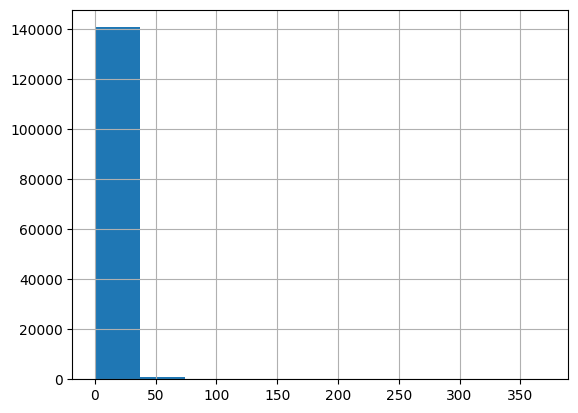

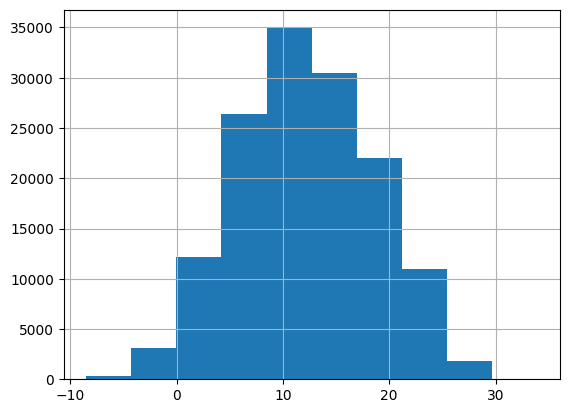

In [124]:
df['Rainfall'].hist()
plt.show() ,

df['MinTemp'].hist()
plt.show()

(<Axes: xlabel='MinTemp', ylabel='Density'>,)

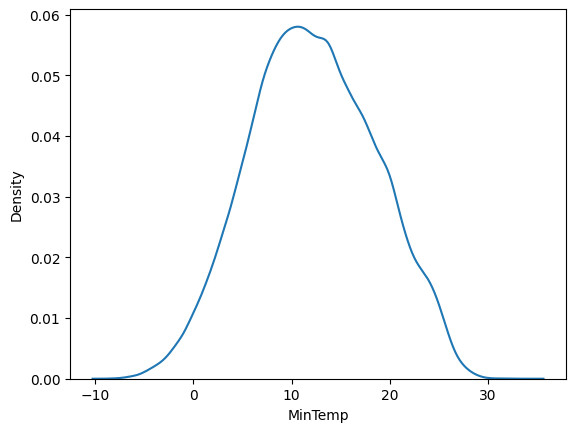

In [125]:
sns.kdeplot(df['MinTemp']),
#sns.kdeplot(df['MaxTemp'])

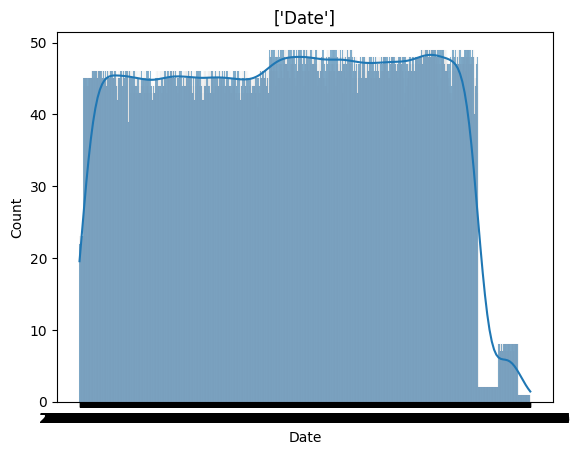

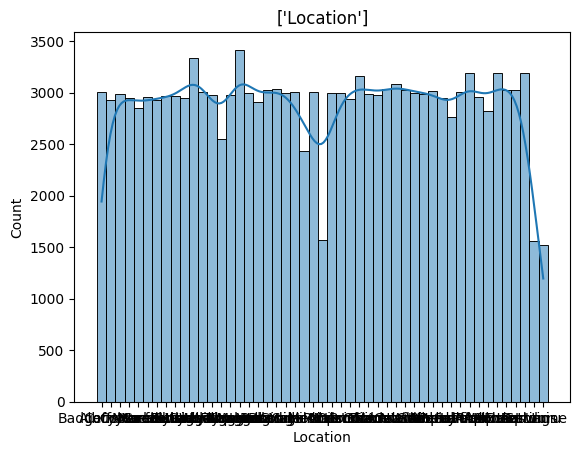

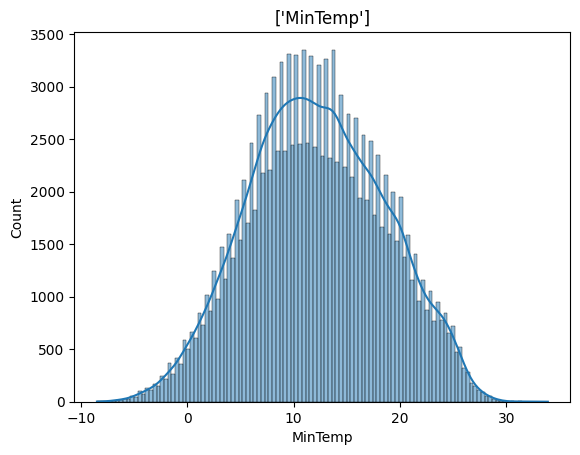

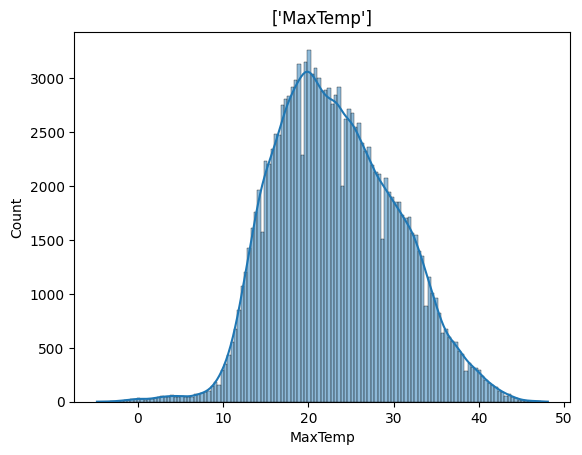

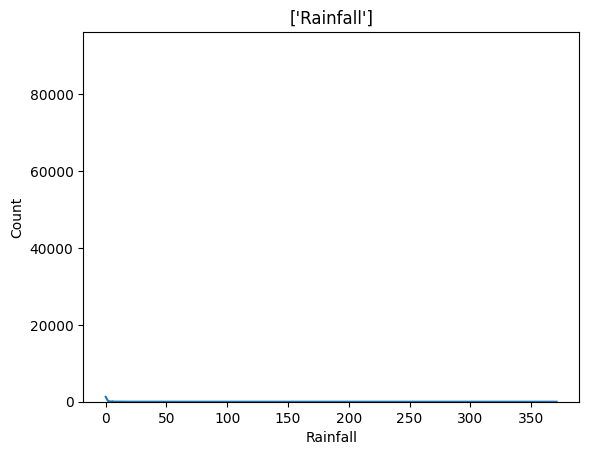

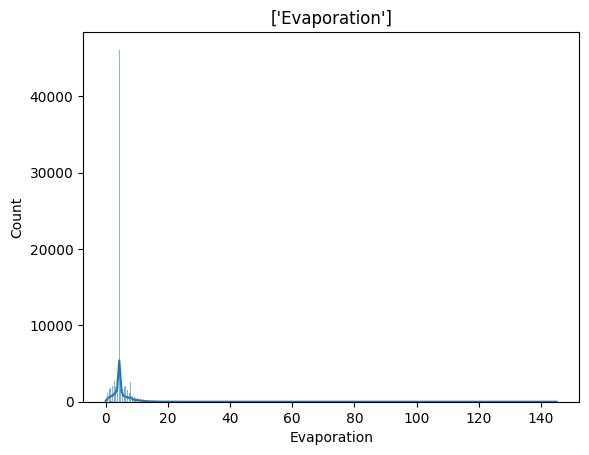

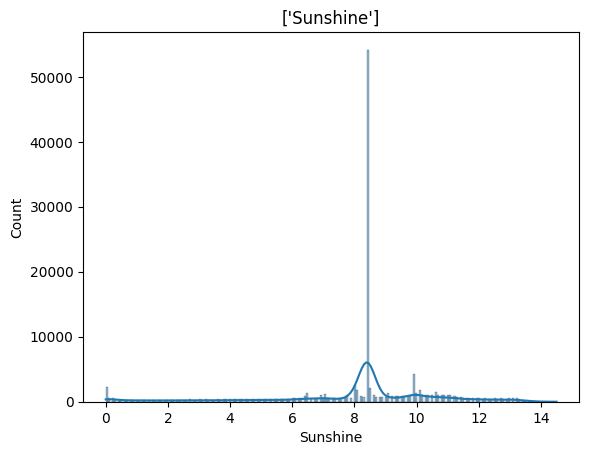

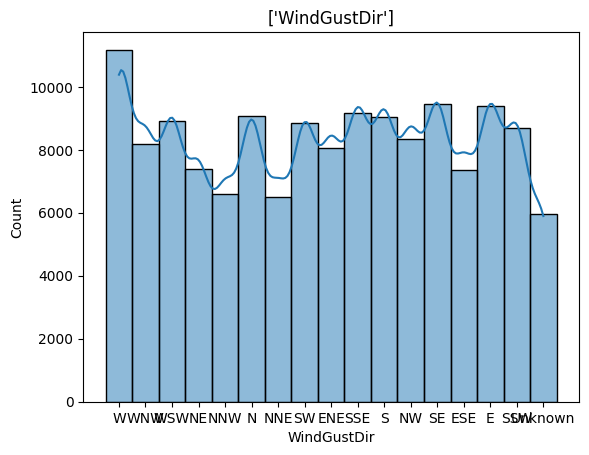

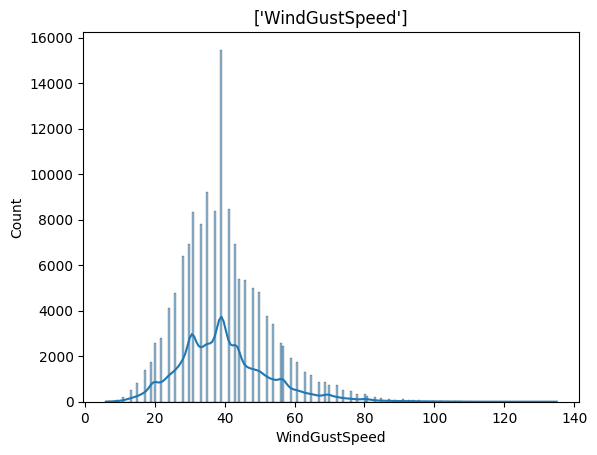

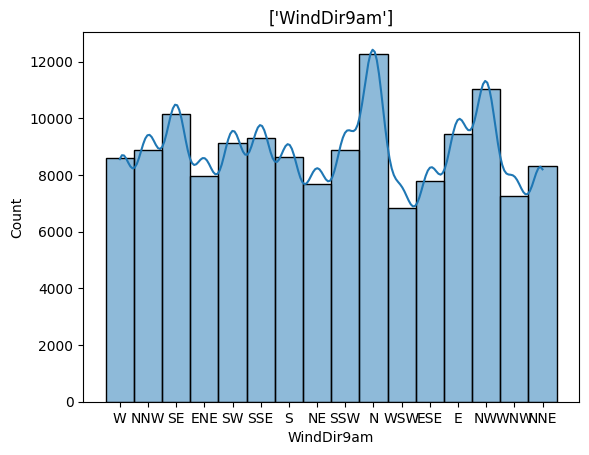

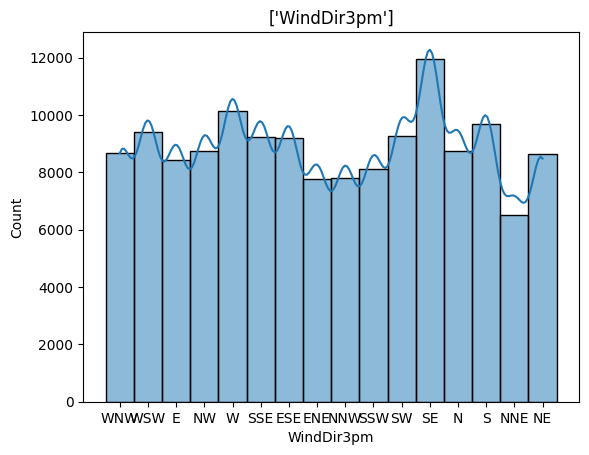

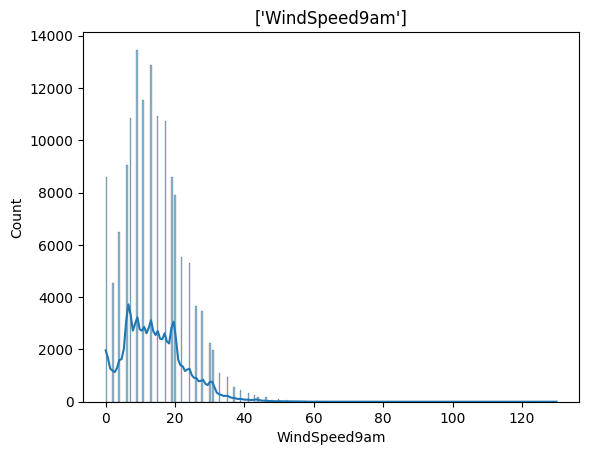

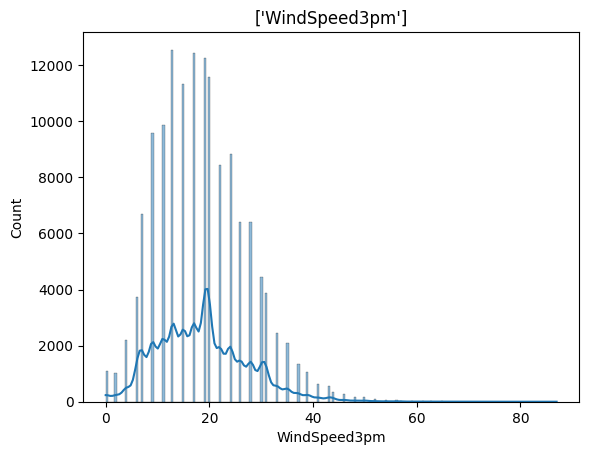

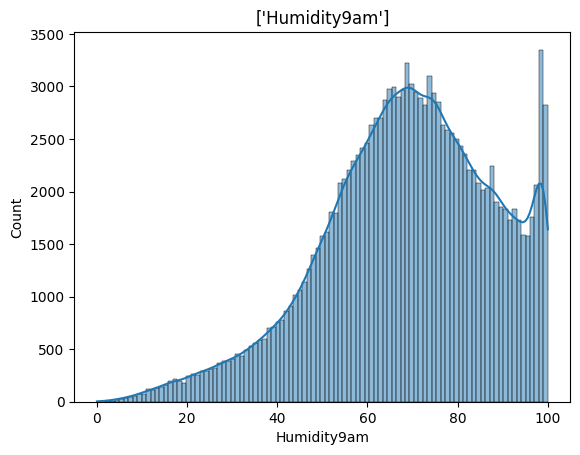

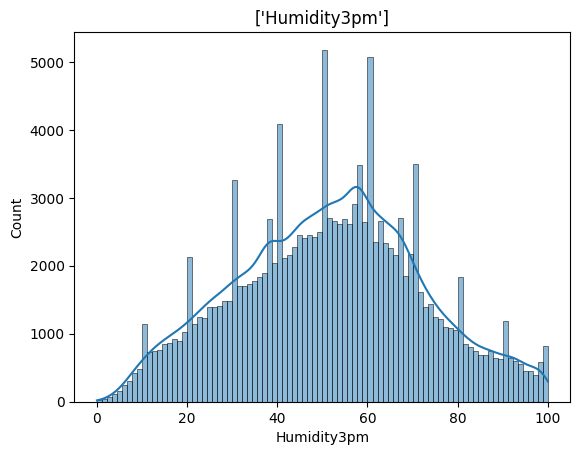

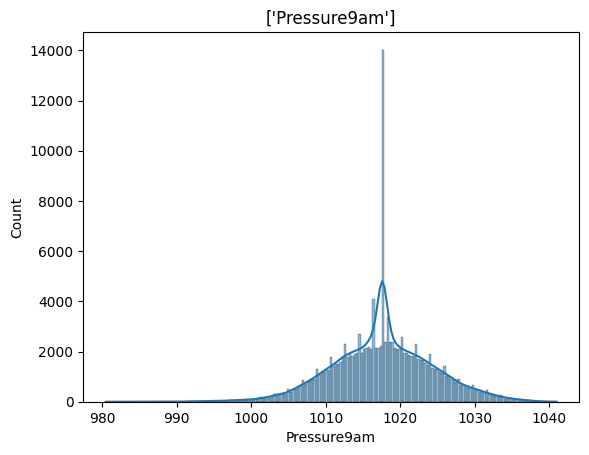

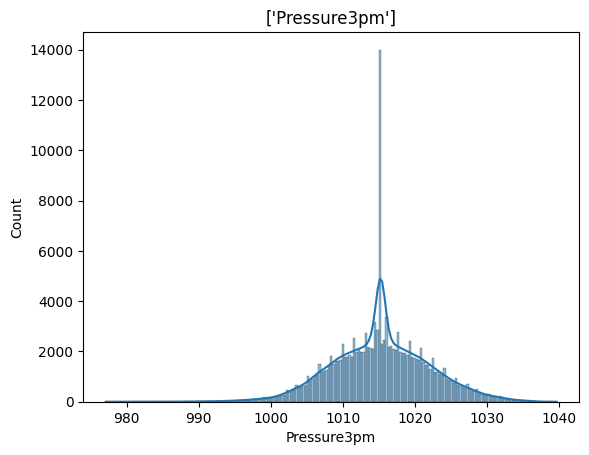

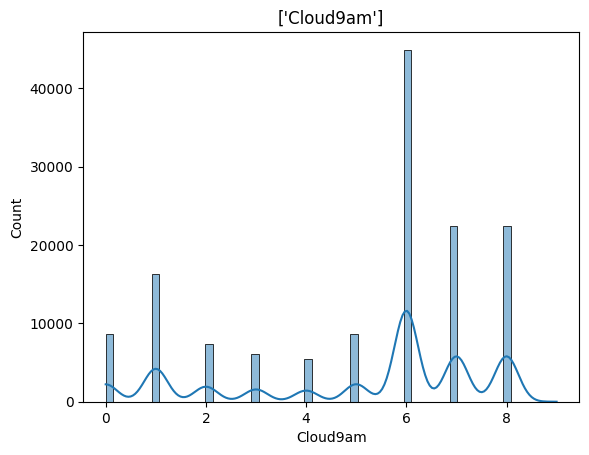

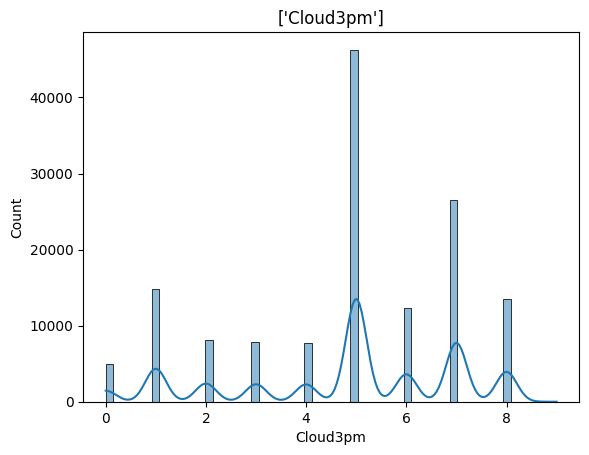

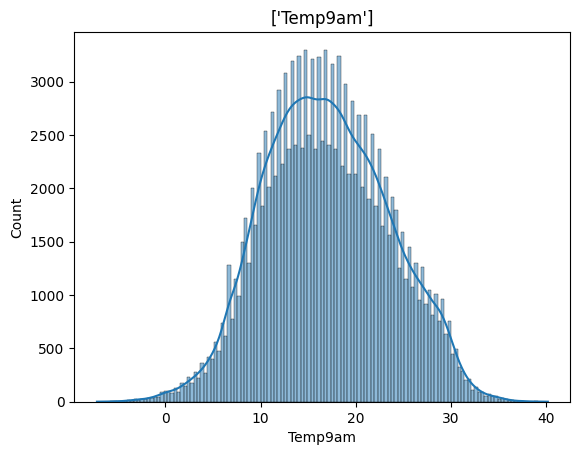

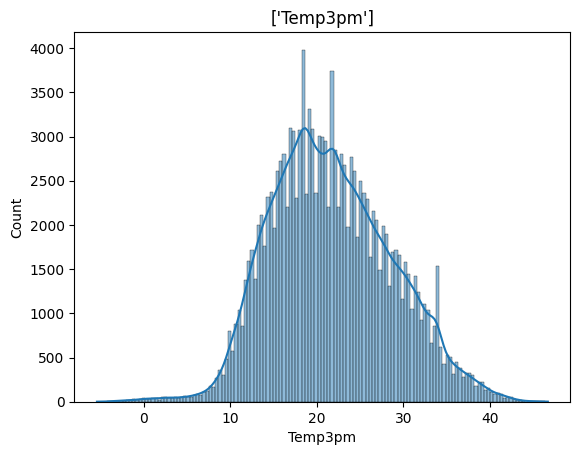

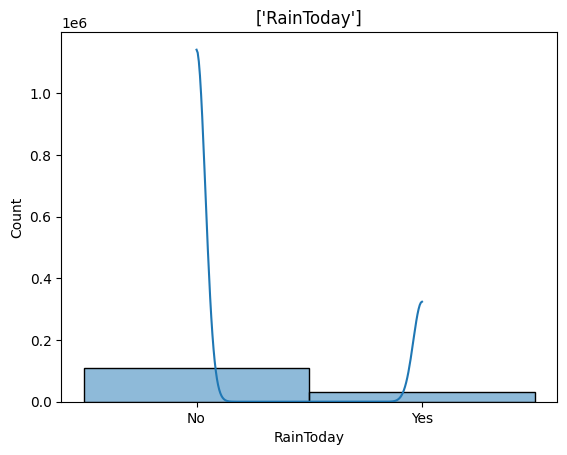

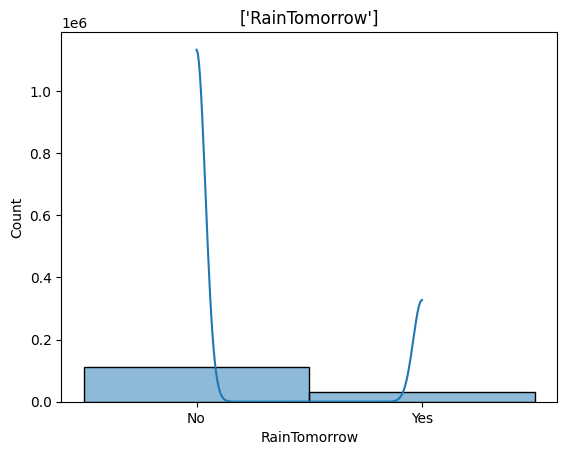

In [126]:
from matplotlib import figure
for col in df:
  sns.histplot(df[col],kde=True)
  plt.title([col])
  plt.show()

# Checking skewnees

In [127]:
df['RainTomorrow'] = df['RainTomorrow'].map({'No':0, 'Yes':1})
df['RainToday'] = df['RainToday'].map({ 'No':0, 'Yes':1})

In [128]:
skewness=df.skew(numeric_only=True)
print(skewness)

MinTemp          0.022802
MaxTemp          0.225167
Rainfall         9.934102
Evaporation      5.023624
Sunshine        -1.040572
WindGustSpeed    0.912883
WindSpeed9am     0.780321
WindSpeed3pm     0.638003
Humidity9am     -0.491853
Humidity3pm      0.025111
Pressure9am     -0.097400
Pressure3pm     -0.045486
Cloud9am        -0.748178
Cloud3pm        -0.554813
Temp9am          0.092786
Temp3pm          0.241817
RainToday        1.343357
RainTomorrow     1.322753
dtype: float64


In [129]:
from scipy.stats import boxcox


df["Sunshine"], _ = boxcox(df["Sunshine"] + 1)
df["Cloud9am"], _ = boxcox(df["Cloud9am"] + 1)
df["Cloud3pm"], _ = boxcox(df["Cloud3pm"] + 1)
df["Humidity9am"], _ = boxcox(df["Humidity9am"] + 1)


In [130]:
df[["Sunshine","Cloud9am","Cloud3pm","Humidity9am"]].skew()

,0
Sunshine,-0.168775
Cloud9am,-0.494187
Cloud3pm,-0.292748
Humidity9am,-0.115170


In [131]:
df['Evaporation'] = np.log1p(df['Evaporation'])
df['WindGustSpeed'] = np.log1p(df['WindGustSpeed'])



In [132]:
df["WindSpeed9am"], _ = boxcox(df["WindSpeed9am"] + 1)
df["WindSpeed3pm"], _ = boxcox(df["WindSpeed3pm"] + 1)


In [133]:
df['Rainfall'] = np.sqrt(df['Rainfall'])

In [134]:
print(df.skew(numeric_only=True))

MinTemp          0.022802
MaxTemp          0.225167
Rainfall         2.929889
Evaporation     -0.184396
Sunshine        -0.168775
WindGustSpeed   -0.285239
WindSpeed9am    -0.057247
WindSpeed3pm     0.016631
Humidity9am     -0.115170
Humidity3pm      0.025111
Pressure9am     -0.097400
Pressure3pm     -0.045486
Cloud9am        -0.494187
Cloud3pm        -0.292748
Temp9am          0.092786
Temp3pm          0.241817
RainToday        1.343357
RainTomorrow     1.322753
dtype: float64


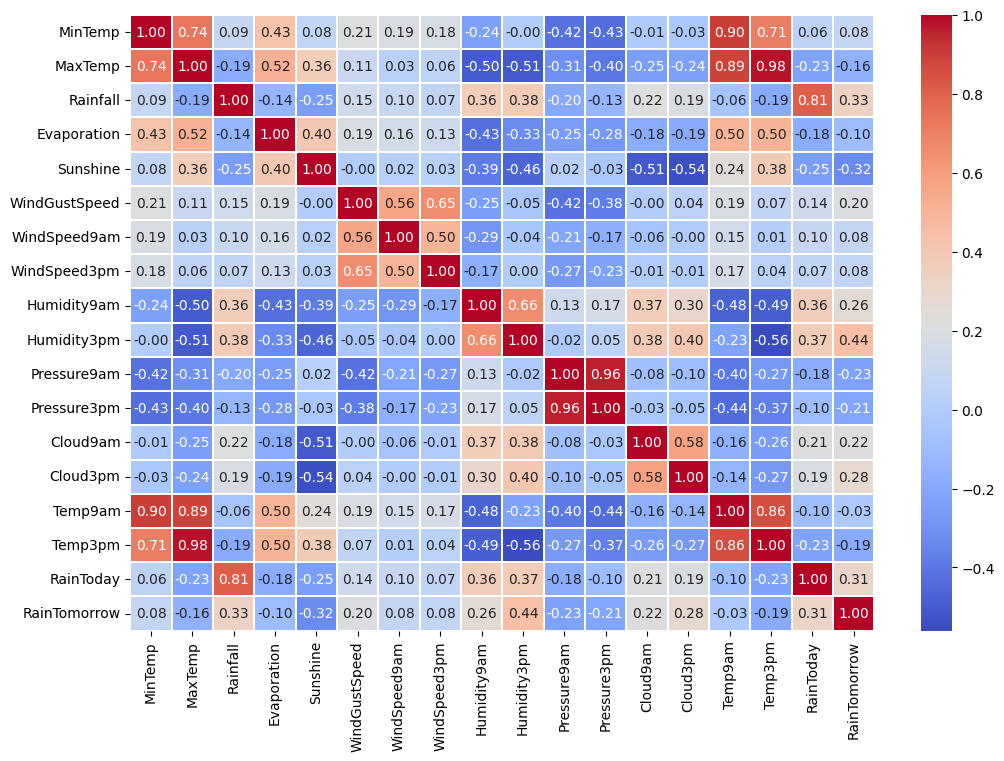

In [135]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.2)
plt.show('corration between variables')

## Feature enggineering

In [136]:
df['Date'] = pd.to_datetime(df['Date'])

In [137]:
df['Month'] = df['Date'].dt.month
df['Month'].head()

,Month
0,12
1,12
2,12
3,12
4,12


In [138]:
df.drop(columns=['Date'],inplace=True)

In [139]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month
0,Albury,13.4,22.9,0.774597,1.686399,25.493352,W,3.806662,W,WNW,...,22.0,1007.7,1007.1,17.118136,11.679925,16.9,21.8,0,0,12
1,Albury,7.4,25.1,0.000000,1.686399,25.493352,WNW,3.806662,NNW,WSW,...,25.0,1010.6,1007.8,17.118136,11.679925,17.2,24.3,0,0,12
2,Albury,12.9,25.7,0.000000,1.686399,25.493352,WSW,3.850148,W,WSW,...,30.0,1007.6,1008.7,17.118136,2.538686,21.0,23.2,0,0,12
3,Albury,9.2,28.0,0.000000,1.686399,25.493352,NE,3.218876,SE,E,...,16.0,1017.6,1012.8,17.118136,11.679925,18.1,26.5,0,0,12
4,Albury,17.5,32.3,1.000000,1.686399,25.493352,W,3.737670,ENE,NW,...,33.0,1010.8,1006.0,14.250968,13.834886,17.8,29.7,0,0,12


In [140]:
# to see range of temp in day
df['TempRange'] = df['MaxTemp'] - df['MinTemp']

In [141]:
# to see avg temp in day
df['AvgTemp'] = (df['MinTemp']+df['MaxTemp']) / 2

In [142]:
df['TempChange'] = df['Temp3pm'] - df['Temp9am']

In [143]:
df['PressureChange'] = df['Pressure3pm'] - df['Pressure9am']

In [144]:
df["HumidityChange"] = df["Humidity3pm"] - df["Humidity9am"]

In [145]:
df["WindSpeedChange"] = df["WindSpeed3pm"] - df["WindSpeed9am"]

In [146]:
df['AvgCloud'] = (df['Cloud3pm'] + df['Cloud9am']) / 2

In [147]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,RainToday,RainTomorrow,Month,TempRange,AvgTemp,TempChange,PressureChange,HumidityChange,WindSpeedChange,AvgCloud
0,Albury,13.4,22.9,0.774597,1.686399,25.493352,W,3.806662,W,WNW,...,0,0,12,9.5,18.15,4.9,-0.6,-378.424625,1.466847,14.399031
1,Albury,7.4,25.1,0.000000,1.686399,25.493352,WNW,3.806662,NNW,WSW,...,0,0,12,17.7,16.25,7.1,-2.8,-172.910257,6.566159,14.399031
2,Albury,12.9,25.7,0.000000,1.686399,25.493352,WSW,3.850148,W,WSW,...,0,0,12,12.8,19.30,2.2,1.1,-129.646831,2.284369,9.828411
3,Albury,9.2,28.0,0.000000,1.686399,25.493352,NE,3.218876,SE,E,...,0,0,12,18.8,18.60,8.4,-4.8,-188.547018,-0.587890,14.399031
4,Albury,17.5,32.3,1.000000,1.686399,25.493352,W,3.737670,ENE,NW,...,0,0,12,14.8,24.90,11.9,-4.8,-462.467996,4.623035,14.042927


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 30 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Location         142193 non-null  object 
 1   MinTemp          142193 non-null  float64
 2   MaxTemp          142193 non-null  float64
 3   Rainfall         142193 non-null  float64
 4   Evaporation      142193 non-null  float64
 5   Sunshine         142193 non-null  float64
 6   WindGustDir      142193 non-null  object 
 7   WindGustSpeed    142193 non-null  float64
 8   WindDir9am       142193 non-null  object 
 9   WindDir3pm       142193 non-null  object 
 10  WindSpeed9am     142193 non-null  float64
 11  WindSpeed3pm     142193 non-null  float64
 12  Humidity9am      142193 non-null  float64
 13  Humidity3pm      142193 non-null  float64
 14  Pressure9am      142193 non-null  float64
 15  Pressure3pm      142193 non-null  float64
 16  Cloud9am         142193 non-null  float64
 

# Encoding category to numeric


In [149]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder


In [150]:
df.shape

(142193, 30)

In [151]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_cat = encoder.fit_transform(df[['Location','WindGustDir','WindDir9am','WindDir3pm']])

In [152]:
encoded_cols = encoder.get_feature_names_out()
df_encoded = pd.DataFrame(X_cat, columns=encoded_cols)

In [153]:
df_encoded.shape

(142193, 94)

In [154]:
df_encoded.head(1)

,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Detecting outliears

In [155]:
df['Month']=df['Month'].astype(np.float64)
(df['Month'].dtype)

dtype('float64')

In [156]:
num_cols = df.select_dtypes(include=['float64']).columns
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'Month', 'TempRange', 'AvgTemp', 'TempChange',
       'PressureChange', 'HumidityChange', 'WindSpeedChange', 'AvgCloud'],
      dtype='object')

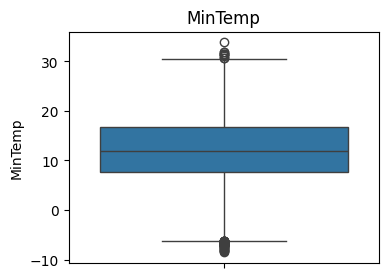

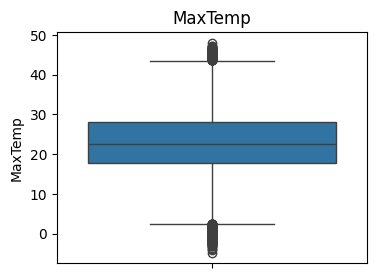

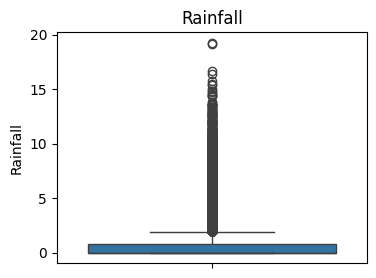

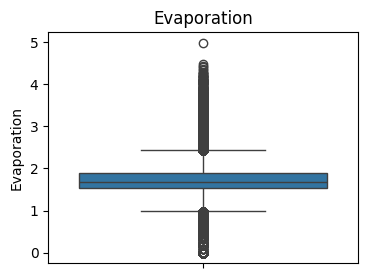

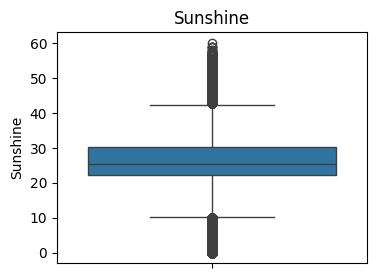

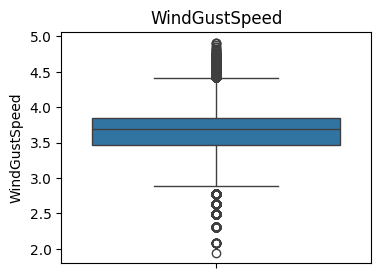

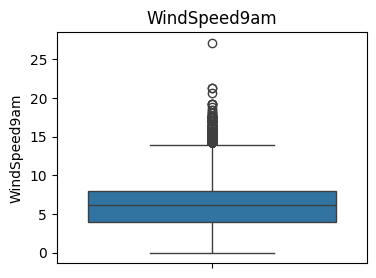

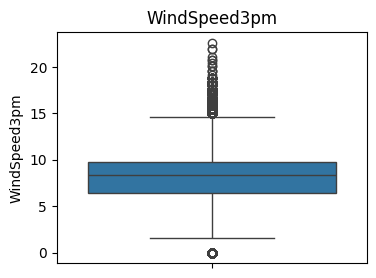

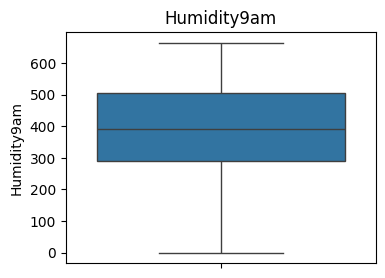

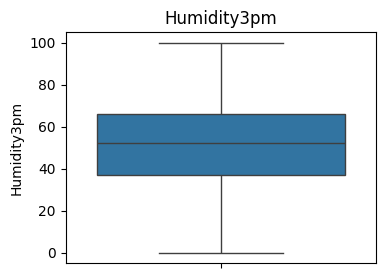

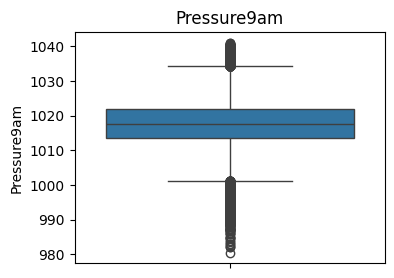

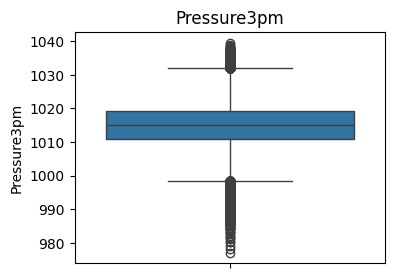

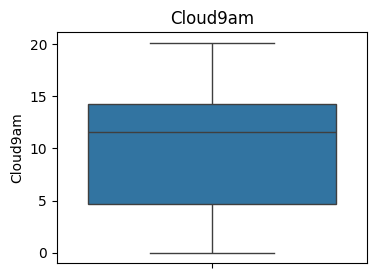

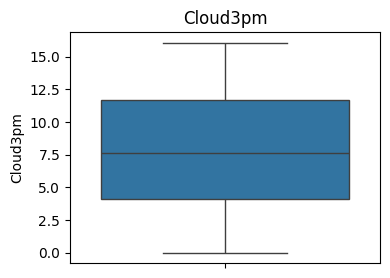

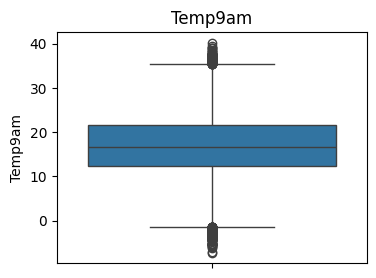

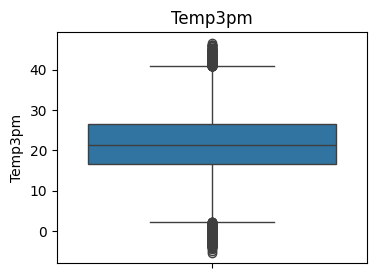

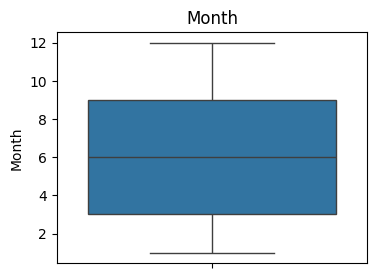

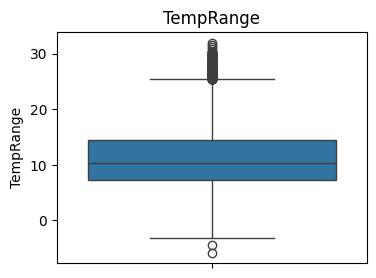

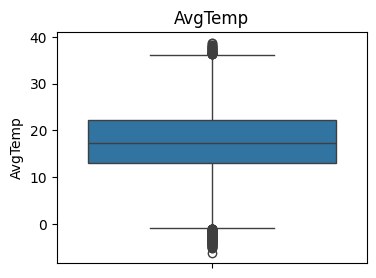

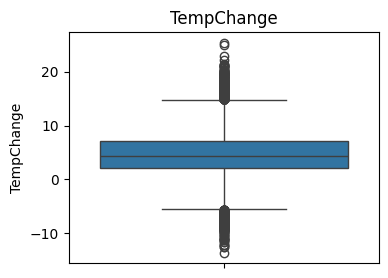

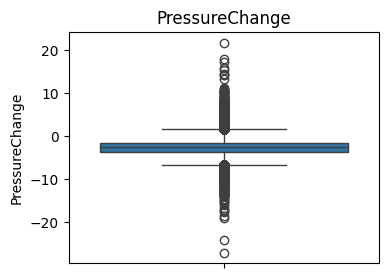

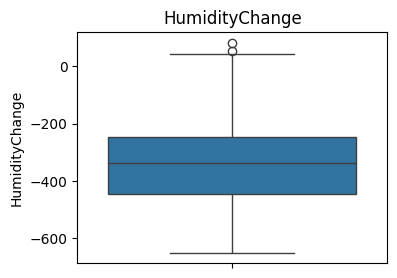

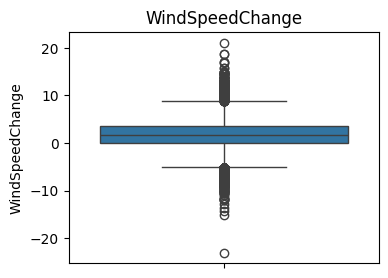

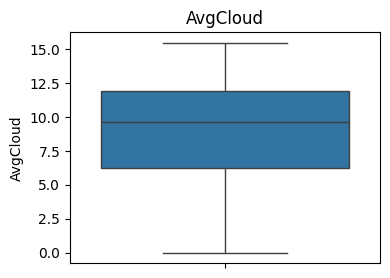

In [157]:
for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [158]:
# use cliping to get extreme values
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR

  df[col] = np.clip(df[col],lower,upper)

In [159]:
df.shape

(142193, 30)

In [160]:
#for col in num_cols:
 ####plt.show()

# checking multicollinarity

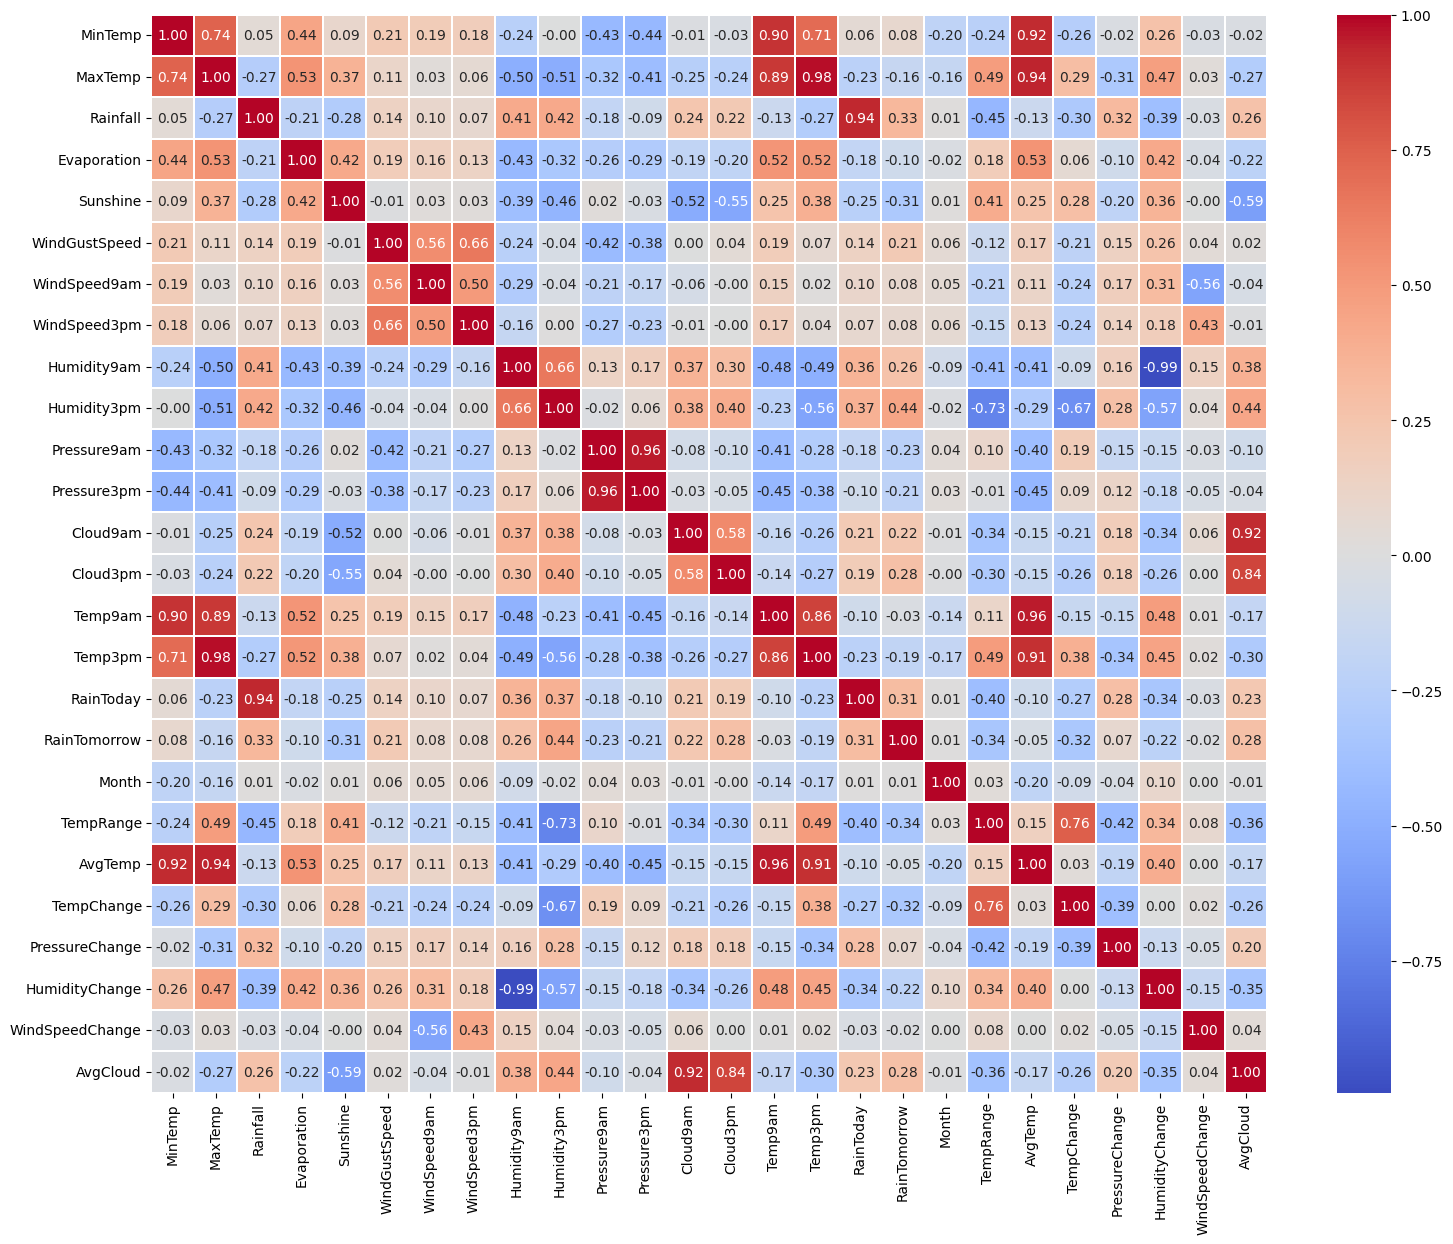

In [161]:
plt.figure(figsize=(18,14))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.1)
plt.show('corration between variables')

In [162]:
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'Month', 'TempRange', 'AvgTemp', 'TempChange',
       'PressureChange', 'HumidityChange', 'WindSpeedChange', 'AvgCloud'],
      dtype='object')

In [163]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["Feature"] = num_cols
vif["VIF"] = [variance_inflation_factor(df[num_cols].values, i) for i in range(len(num_cols))]

print(vif)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


            Feature           VIF
0           MinTemp  5.060879e+04
1           MaxTemp  1.210906e+05
2          Rainfall  2.129188e+00
3       Evaporation  3.658687e+01
4          Sunshine  1.755912e+01
5     WindGustSpeed  2.922452e+02
6      WindSpeed9am  6.645447e+02
7      WindSpeed3pm  1.053635e+03
8       Humidity9am  2.925337e+07
9       Humidity3pm  5.068481e+05
10      Pressure9am  5.312563e+06
11      Pressure3pm  5.287323e+06
12         Cloud9am           inf
13         Cloud3pm           inf
14          Temp9am  9.498474e+03
15          Temp3pm  1.488616e+04
16            Month  5.093638e+00
17        TempRange  7.571800e+03
18          AvgTemp  2.603960e+05
19       TempChange  1.031267e+03
20   PressureChange  5.328572e+01
21   HumidityChange  2.240798e+07
22  WindSpeedChange  1.638758e+02
23         AvgCloud           inf


In [164]:
high_vif = ['Humidity9am','Pressure3pm','MinTemp'
            ,'Temp9am','Cloud3pm','WindSpeed9am']
new_viff = num_cols.drop(high_vif)

In [165]:
new_viff

Index(['MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed',
       'WindSpeed3pm', 'Humidity3pm', 'Pressure9am', 'Cloud9am', 'Temp3pm',
       'Month', 'TempRange', 'AvgTemp', 'TempChange', 'PressureChange',
       'HumidityChange', 'WindSpeedChange', 'AvgCloud'],
      dtype='object')

In [166]:
vif_data = pd.DataFrame()
vif_data['Feature'] = new_viff
vif_data['VIF'] = [variance_inflation_factor(df[new_viff].values, i) for i in range(len(new_viff))]
print(vif_data.sort_values('VIF', ascending=False))

            Feature           VIF
0           MaxTemp  66297.017771
12          AvgTemp  38812.082229
11        TempRange   4087.775032
9           Temp3pm    535.098042
7       Pressure9am    331.184615
4     WindGustSpeed    291.783835
17         AvgCloud     42.791400
2       Evaporation     36.578188
6       Humidity3pm     35.947998
8          Cloud9am     29.806202
5      WindSpeed3pm     27.266367
15   HumidityChange     23.739305
13       TempChange     17.831796
3          Sunshine     17.556865
10            Month      5.092845
14   PressureChange      4.159361
16  WindSpeedChange      2.343049
1          Rainfall      2.127675


In [167]:
new_viff1 = new_viff.drop(['MaxTemp','Temp3pm','Pressure9am','WindGustSpeed'])

In [168]:
vif_data = pd.DataFrame()
vif_data['Feature'] = new_viff1
vif_data['VIF'] = [variance_inflation_factor(df[new_viff1].values, i) for i in range(len(new_viff1))]
print(vif_data.sort_values('VIF', ascending=False))

            Feature        VIF
13         AvgCloud  41.775145
1       Evaporation  33.127267
5          Cloud9am  29.728527
4       Humidity3pm  26.979554
11   HumidityChange  22.490784
7         TempRange  19.098082
2          Sunshine  16.020448
8           AvgTemp  14.072007
9        TempChange  13.064500
3      WindSpeed3pm  12.850747
6             Month   4.805713
10   PressureChange   4.083292
0          Rainfall   2.059416
12  WindSpeedChange   1.985935


In [169]:
new_df = new_viff1.drop(['Cloud9am','Humidity3pm','Evaporation','TempRange'])

In [170]:
vif_data = pd.DataFrame()
vif_data['Feature'] = new_df
vif_data['VIF'] = [variance_inflation_factor(df[new_df].values, i) for i in range(len(new_df))]
print(vif_data.sort_values('VIF', ascending=False))

           Feature        VIF
2     WindSpeed3pm  11.759695
1         Sunshine  11.485833
4          AvgTemp   9.969422
7   HumidityChange   8.869888
9         AvgCloud   6.935266
3            Month   4.436256
6   PressureChange   3.874657
5       TempChange   3.821295
0         Rainfall   2.009566
8  WindSpeedChange   1.862521


In [171]:
df_encoded=pd.DataFrame(df_encoded)

In [172]:
df_encoded.dtypes

,0
Location_Albany,float64
Location_Albury,float64
Location_AliceSprings,float64
Location_BadgerysCreek,float64
Location_Ballarat,float64
...,...
WindDir3pm_SSW,float64
WindDir3pm_SW,float64
WindDir3pm_W,float64
WindDir3pm_WNW,float64


In [173]:
df_encoded = df_encoded.columns.tolist()

In [174]:
#df_encoded.head()

# scaling and spliting data

In [175]:
import pandas as pd
# Numerical features to keep from df (based on VIF analysis and 'RainToday')
# 'new_df' is a pandas Index object from the VIF analysis, so convert to list
features_from_df = new_df.tolist() + ['RainToday']

# Reconstruct df_encoded as a DataFrame since it was previously converted to a list of column names
df_encoded = pd.DataFrame(X_cat, columns=encoded_cols)

# Ensure df_encoded has the same index as df for correct concatenation
# This handles cases where df's index might have gaps after dropna
df_encoded = df_encoded.set_index(df.index)

# Create x by concatenating selected numerical features from df and the one-hot encoded features
# These features will not include 'RainTomorrow' or other target/dropped features by design
x = pd.concat([df[features_from_df], df_encoded], axis=1)

# Define y as the target variable
y = df['RainTomorrow']

In [176]:
x.head()

,Rainfall,Sunshine,WindSpeed3pm,Month,AvgTemp,TempChange,PressureChange,HumidityChange,WindSpeedChange,AvgCloud,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,0.774597,25.493352,9.776384,12.0,18.15,4.9,-0.6,-378.424625,1.466847,14.399031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.000000,25.493352,9.220039,12.0,16.25,7.1,-2.8,-172.910257,6.566159,14.399031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.000000,25.493352,10.315071,12.0,19.30,2.2,1.1,-129.646831,2.284369,9.828411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.000000,25.493352,4.949878,12.0,18.60,8.4,-4.8,-188.547018,-0.587890,14.399031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000000,25.493352,8.643838,12.0,24.90,11.9,-4.8,-462.467996,4.623035,14.042927,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [177]:
from sklearn.model_selection import train_test_split

In [178]:
X_train, X_test ,Y_train ,Y_test = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y )

In [179]:
X_train.shape, X_test.shape

((113754, 105), (28439, 105))

In [180]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



In [181]:
type(X_train_scaled)

numpy.ndarray

In [182]:
X_train_scaled = pd.DataFrame(X_train_scaled)
X_test_scaled  = pd.DataFrame(X_test_scaled)

# Model Training

In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score ,log_loss, f1_score, roc_auc_score,classification_report

In [184]:
from imblearn.over_sampling import SMOTE #smote techniqe to handle imbalanced dataset

smote = SMOTE(random_state=42)
X_retrain, y_retrain = smote.fit_resample(X_train_scaled, Y_train)

In [185]:
model = LogisticRegression(class_weight='balanced', random_state=42,max_iter=1000)
model.fit(X_retrain, y_retrain)
y_pred = model.predict(X_test_scaled)

In [186]:
y_prob = model.predict_proba(X_test_scaled)[:,1]


In [187]:
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

Accuracy: 0.7552304933366152

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.83     22064
           1       0.47      0.76      0.58      6375

    accuracy                           0.76     28439
   macro avg       0.69      0.76      0.70     28439
weighted avg       0.82      0.76      0.77     28439



In [188]:
print("ROC-AUC:", roc_auc_score(Y_test, y_prob))


ROC-AUC: 0.8358449714911345


In [189]:
print("Log Loss:", log_loss(Y_test, y_prob))

Log Loss: 0.4960760309787385


# dumpping file

In [190]:
columns_for_inference = X_train.columns.tolist()
columns_for_inference

['Rainfall',
 'Sunshine',
 'WindSpeed3pm',
 'Month',
 'AvgTemp',
 'TempChange',
 'PressureChange',
 'HumidityChange',
 'WindSpeedChange',
 'AvgCloud',
 'RainToday',
 'Location_Albany',
 'Location_Albury',
 'Location_AliceSprings',
 'Location_BadgerysCreek',
 'Location_Ballarat',
 'Location_Bendigo',
 'Location_Brisbane',
 'Location_Cairns',
 'Location_Canberra',
 'Location_Cobar',
 'Location_CoffsHarbour',
 'Location_Dartmoor',
 'Location_Darwin',
 'Location_GoldCoast',
 'Location_Hobart',
 'Location_Katherine',
 'Location_Launceston',
 'Location_Melbourne',
 'Location_MelbourneAirport',
 'Location_Mildura',
 'Location_Moree',
 'Location_MountGambier',
 'Location_MountGinini',
 'Location_Newcastle',
 'Location_Nhil',
 'Location_NorahHead',
 'Location_NorfolkIsland',
 'Location_Nuriootpa',
 'Location_PearceRAAF',
 'Location_Penrith',
 'Location_Perth',
 'Location_PerthAirport',
 'Location_Portland',
 'Location_Richmond',
 'Location_Sale',
 'Location_SalmonGums',
 'Location_Sydney',
 'Lo

In [191]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [192]:
import os

print("Saved size:", os.path.getsize("model.pkl"))

Saved size: 1727


In [193]:
print(model)
print(type(model))

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [194]:
hasattr(model, "coef_")  # for linear models

True